# Análisis Exploratorio de Datos

In [1]:
import sys
from pathlib import Path
import io
import os
import base64
import numpy as np
import pywt
import pandas as pd
from statsmodels.tsa import seasonal
import matplotlib.transforms as mtransforms
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display, HTML
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, kpss

PROJECT_ROOT = Path.cwd().parent
SRC_PATH     = PROJECT_ROOT / "src"
DATA_PATH    = PROJECT_ROOT / "data" / "raw" / "brent_raw.parquet"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

df = pd.read_parquet(DATA_PATH)

In [2]:
from IPython.display import SVG, display

def render_figure_vector(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="svg", bbox_inches="tight")
    plt.close(fig)
    svg_data = buf.getvalue().decode("utf-8")
    display(HTML(
        f'<div style="display: flex; justify-content: center; width: 100%;">'
        f'{svg_data}</div>'
    ))

## Introducción

El precio del crudo Brent es una variable macroeconómica y financiera global con alta volatilidad y sensibilidad ante eventos geopolíticos. El modelado de varianza condicional en *commodities* evoluciona hacia arquitecturas híbridas que integran series temporales continuas con información no estructurada. La serie histórica de precios del contrato de futuro continuo del Brent proviene de Yahoo Finance. El contrato es un instrumento financiero estandarizado de negociación a plazo. Cotiza en bolsa y sirve de referencia global de precios.

:::{admonition} Información: Dataset de Futuros del Brent
:class: info

La serie analizada proviene del contrato de futuro continuo del petróleo crudo Brent (*ticker BZ=F* en Yahoo Finance). Comprende 3,154 observaciones en días hábiles de mercado (*business days*), cada una con la estructura de precios diarios OHLC (apertura, máximo, mínimo y cierre) y el volumen de negociación.

El período analizado (2014–2026) abarca múltiples regímenes y shocks estructurales. Estos incluyen la crisis de exceso de oferta (2014–2016), las tensiones geopolíticas y sanciones entre Estados Unidos e Irán, el colapso de demanda por COVID‑19 (2020), y el conflicto de Ucrania (2022).
:::

Las series financieras plantean heterocedasticidad condicional, colas pesadas, cambios estructurales de régimen y propagación de shocks exógenos no anticipados. El Análisis Exploratorio de Datos (EDA) constituye una fase crítica de validación e inferencia cuyo propósito es caracterizar la dinámica estocástica de la serie temporal antes de las fases de modelado de la volatilidad.

Esta libreta documenta la evaluación de la integridad de la base de datos: detección de registros faltantes, discontinuidades en el calendario de cotización bursátil y tratamiento de anomalías. También documenta el análisis de raíz unitaria, estacionariedad, propiedades distributivas y estructura de autocorrelación en media y varianza (efectos ARCH). Se incorpora una descomposición multirresolución en el dominio tiempo‑frecuencia para identificar valores atípicos, cambios de régimen y patrones locales de volatilidad.

## Análisis preliminar

El conjunto de datos estuvo compuesto por 3,177 registros diarios correspondientes a días hábiles de mercado. El período abarcó desde el 2 de enero de 2014 hasta el 21 de agosto de 2026. Las cinco variables analizadas (apertura, máximo, mínimo, cierre y volumen) se almacenaron en formato `float32`. No se identificaron valores faltantes en ninguna de ellas.

In [3]:
df_integrity = pd.DataFrame(
    {
        "Variable": df.columns,
        "Tipo de Datos": [str(dtype) for dtype in df.dtypes],
        "Valores Faltantes": df.isnull().sum().values,
    }
)


def smart_format(x, fmt):
    if pd.isna(x) or isinstance(x, str):
        return x
    try:
        return fmt.format(x)
    except (ValueError, TypeError):
        return x


format_dict_integrity = {
    "Valores Faltantes": lambda x: smart_format(x, "{:,.0f}")
}

styled_integrity = df_integrity.style.hide(axis="index").set_table_styles(
    [
        {
            "selector": "",
            "props": [
                ("margin-left", "auto"),
                ("margin-right", "auto"),
                ("width", "auto"),
                ("border-collapse", "collapse"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("background-color", "#f2f2f2"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("border", "1px solid black"),
                ("padding", "10px"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid black"),
                ("padding", "10px"),
            ],
        },
        {
            "selector": "th:first-child",
            "props": [("text-align", "left")],
        },
        {
            "selector": "td:first-child",
            "props": [("text-align", "left")],
        },
    ]
)

styled_integrity = styled_integrity.format(format_dict_integrity)
display(
    HTML(
        "<div style='text-align: center; width: 100%;'>"
        + styled_integrity.to_html()
        + "</div>"
    )
)

Variable,Tipo de Datos,Valores Faltantes
close,float32,0
high,float32,0
low,float32,0
open,float32,0
volume,float32,0


El conjunto de datos se dividió en dos segmentos: entrenamiento y prueba. El segmento de entrenamiento incluyó 2,223 observaciones, del 2 de enero de 2014 al 3 de noviembre de 2022. El segmento de prueba incluyó 954 observaciones, del 4 de noviembre de 2022 al 21 de agosto de 2026. La proporción fue 70% para entrenamiento y 30% para prueba. El análisis exploratorio se realizó exclusivamente sobre el segmento de entrenamiento. El segmento de prueba no se procesó.

In [4]:
df = df.sort_index()
split_idx = int(len(df) * 0.70)
df_train = df.iloc[:split_idx].copy()
df_test = df.iloc[split_idx:].copy()

fig, ax = plt.subplots(figsize=(7, 3.5), dpi=300)

ax.set_title("Precio de cierre del petróleo Brent", fontsize=12, pad=12)

ax.axvline(
    x=df_test.index[0], color="black", linestyle=":", linewidth=1.0, alpha=0.8
)

ax.plot(df_train.index, df_train["close"], color="black", linewidth=1.0)
ax.plot(df_test.index, df_test["close"], color="black", linewidth=1.0)

xlim_orig = ax.get_xlim()

ax.fill_betweenx(
    y=[0, 1],
    x1=df_test.index[0],
    x2=df.index[-1] + pd.Timedelta(days=300),
    transform=ax.get_xaxis_transform(),
    color="lightgray",
    alpha=0.3,
)

ax.set_xlim(xlim_orig)

mid_train = df_train.index[len(df_train) // 2]
mid_test = df_test.index[len(df_test) // 2]

trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)

ax.text(
    mid_train,
    0.80,
    "Entrenamiento",
    transform=trans,
    ha="center",
    va="bottom",
    fontsize=12,
    color="black",
)

ax.text(
    mid_test,
    0.80,
    "Prueba",
    transform=trans,
    ha="center",
    va="bottom",
    fontsize=12,
    color="black",
)

ax.set_xlabel("Fecha", fontsize=10, labelpad=9)
ax.set_ylabel("Precio (USD/bbl)", fontsize=10, labelpad=9)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.8)

ax.tick_params(
    axis="x",
    which="both",
    bottom=True,
    labelsize=9,
    direction="out",
    length=4,
    width=0.8,
    colors="black",
)
ax.tick_params(
    axis="y",
    which="both",
    left=True,
    labelsize=9,
    direction="out",
    length=4,
    width=0.8,
    colors="black",
)

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
render_figure_vector(fig)

:::{admonition} Nota: Partición temporal
:class: note
La partición respetó el orden cronológico de los registros. No se aplicó barajado aleatorio. El conjunto de prueba funciona como *holdout set* y permanece intacto para evaluar el desempeño fuera de muestra. Esta estrategia evita la fuga de información entre los conjuntos.
:::

El precio de cierre constituyó la serie principal de referencia. Los retornos logarítmicos diarios se calcularon como $r_t = \ln(P_t/P_{t-1})$. La volatilidad se aproximó mediante dos proxies: los retornos al cuadrado $r_t^2$ y el estimador de rango de Garman‑Klass (GK). El estimador GK utiliza los precios de apertura, máximo, mínimo y cierre para representar la variabilidad intradía. Las series derivadas se calcularon sobre el segmento de entrenamiento.

In [5]:
term_hl = np.log(df_train['high'] / df_train['low']) ** 2
term_co = np.log(df_train['close'] / df_train['open']) ** 2
df_train['gk_daily'] = 0.511 * term_hl - (2 * np.log(2) - 1) * term_co

df_train["log_returns"] = np.log(df_train["close"] / df_train["close"].shift(1))
df_train["squared_returns"] = df_train["log_returns"] ** 2

cols_target = ["close", "log_returns", "squared_returns", "gk_daily"]
df_stats = df_train[cols_target].dropna()

Las estadísticas descriptivas indicaron asimetría positiva en el precio de cierre, con media superior a la mediana. Los retornos logarítmicos mostraron una media cercana a cero y valores extremos que sugieren colas pesadas. Las dos aproximaciones de volatilidad, retornos al cuadrado y estimador Garman‑Klass, presentaron medias y cuartiles próximos, lo que indica consistencia en la captura de la variabilidad diaria. La concentración de la masa en valores bajos frente a máximos elevados apuntan a un agrupamiento de volatilidad.

In [6]:
def get_stats_summary(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return pd.Series(
        {
            "Registros": len(series),
            "Media": series.mean(),
            "Desv. Est.": series.std(),
            "Mínimo": series.min(),
            "Cuartil 1": q1,
            "Mediana": series.median(),
            "Cuartil 3": q3,
            "Máximo": series.max(),
            "IQR": iqr,
        }
    )

df_summary = df_stats.apply(get_stats_summary)

df_summary.columns = [
    "Precio de cierre",
    "Retornos logarítmicos",
    "Retornos al cuadrado",
    "Volatilidad realizada (GK)",
]

df_audit = df_summary.reset_index().rename(columns={"index": "Parámetro"})

numeric_cols = df_audit.columns[1:]
df_audit[numeric_cols] = df_audit[numeric_cols].map(lambda x: 0.0 if abs(x) < 0.00005 else x)

mask_registros = df_audit["Parámetro"] == "Registros"

styled_audit = (
    df_audit.style
    .hide(axis="index")
    .set_table_styles(
        [
            {
                "selector": "",
                "props": [
                    ("margin-left", "auto"),
                    ("margin-right", "auto"),
                    ("width", "auto"),
                    ("border-collapse", "collapse"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("vertical-align", "middle"),
                    ("background-color", "#f2f2f2"),
                    ("color", "black"),
                    ("font-weight", "bold"),
                    ("border", "1px solid black"),
                    ("padding", "10px"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "center"),
                    ("vertical-align", "middle"),
                    ("border", "1px solid black"),
                    ("padding", "10px"),
                ],
            },
            {
                "selector": "th:first-child",
                "props": [
                    ("text-align", "left"),
                    ("vertical-align", "middle"),
                ],
            },
            {
                "selector": "td:first-child",
                "props": [
                    ("text-align", "left"),
                    ("vertical-align", "middle"),
                ],
            },
        ]
    )
    .format("{:,.0f}", subset=pd.IndexSlice[mask_registros, numeric_cols])
    .format("{:,.4f}", subset=pd.IndexSlice[~mask_registros, numeric_cols])
)

display(
    HTML(
        "<div style='text-align: center; width: 100%;'>"
        + styled_audit.to_html()
        + "</div>"
    )
)

Parámetro,Precio de cierre,Retornos logarítmicos,Retornos al cuadrado,Volatilidad realizada (GK)
Registros,"2,222","2,222","2,222","2,222"
Media,66.4671,-0.0001,0.0007,0.0006
Desv. Est.,21.6286,0.0259,0.0029,0.0022
Mínimo,19.3300,-0.2798,0.0000,0.0000
Cuartil 1,50.3650,-0.0104,0.0000,0.0001
Mediana,62.7350,0.0008,0.0001,0.0003
Cuartil 3,76.4975,0.0115,0.0005,0.0006
Máximo,127.9800,0.1908,0.0783,0.0658
IQR,26.1325,0.0220,0.0005,0.0004


Las estadísticas descriptivas no son representativas por sí solas de la dinámica de precios. No se evaluó la estacionariedad de las series. Una serie no estacionaria presenta media, varianza u otros momentos que dependen del tiempo; los valores descriptivos globales combinan regímenes distintos y no describen un periodo específico. Las próximas secciones presentan un análisis detallado de cada serie, su estacionariedad y posibles eventos atípicos. El EDA culmina con el estudio de la dependencia entre los retornos al cuadrado y el estimador Garman‑Klass para la volatilidad realizada.

:::{admonition} Información: Estimador de Volatilidad de Garman‑Klass
:class: info

El estimador de rango de Garman‑Klass (GK) captura la variabilidad intradía sin depender únicamente de los precios de cierre. Considera la trayectoria diaria de apertura ($O_t$), máximo ($H_t$), mínimo ($L_t$) y cierre ($C_t$):

$$
GK_t = 0.511 \left[\ln\left(\frac{H_t}{L_t}\right)\right]^2 - (2\ln 2 - 1)\left[\ln\left(\frac{C_t}{O_t}\right)\right]^2
$$

El estimador GK logra mayor eficiencia asintótica que la volatilidad basada en retornos de cierre a cierre; esto es: reduce la varianza del estimador al aprovechar la información intradía de precios en comparación con los retornos al cuadrado.
:::

## Precio de cierre

El precio de cierre presentó cuatro episodios de cambio de nivel y volatilidad. El colapso 2014–2016 llevó el precio desde 110 hasta 30 USD/bbl. El auge del petróleo de esquisto en EE.UU. y la defensa de cuotas de mercado por la OPEP estuvieron asociados al descenso. La recuperación 2017–2019 mantuvo el precio entre 50 y 80 USD/bbl. Los acuerdos de recorte OPEP+ respaldaron ese rango. El desplome pandémico de 2020 situó el precio cerca de 20 USD/bbl. El confinamiento global y la parálisis industrial redujeron la demanda. El rally post‑pandemia 2021–2022 superó los 120 USD/bbl. La reactivación económica y las tensiones geopolíticas en Europa del Este impulsaron el alza.

In [29]:
df_plot = df_train.copy()
df_plot["year"] = df_plot.index.year

years = sorted(df_plot["year"].unique())
box_data = [df_plot[df_plot["year"] == yr]["close"].values for yr in years]

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(8, 4),
    dpi=300,
)

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )
    ax.tick_params(
        axis="y",
        which="both",
        left=True,
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

ax1.plot(df_plot.index, df_plot["close"], color="black", linewidth=1.0)
ax1.set_xlabel("Fecha", fontsize=12, labelpad=9)
ax1.set_ylabel("Precio (USD/bbl)", fontsize=12, labelpad=9)
ax1.set_title("Precio de cierre", fontsize=12, pad=12)

ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

bp = ax2.boxplot(
    box_data,
    positions=years,
    widths=0.6,
    patch_artist=True,
    flierprops={
        "marker": "o",
        "markersize": 1.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markeredgewidth": 0.5,
    },
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 0.8},
)

even_years = [yr for yr in years if yr % 2 == 0]
ax2.set_xticks(even_years)
ax2.set_xticklabels(even_years, rotation=0)
ax2.set_xlim(min(years) - 0.8, max(years) + 0.8)

ax2.set_xlabel("Año", fontsize=12, labelpad=9)
ax2.set_title("Distribución anual del precio", fontsize=12, pad=12)

ax2.tick_params(
    axis="y",
    which="both",
    left=False,
    right=False,
    labelleft=False,
    labelright=False,
)

plt.tight_layout()
render_figure_vector(fig)

Los diagramas de caja anuales no fueron homogéneos. La mediana y la amplitud intercuartílica variaron entre años. El año 2014 presentó una distribución asimétrica con valores atípicos en la cola inferior. El año 2016 mostró una caja compacta en precios de cierre más bajos. El año 2020 registró una mediana baja y valores atípicos superiores. El año 2022 desplazó la distribución hacia el segmento superior. Estos patrones sugirieron que la variabilidad del precio no fue constante en el tiempo. La variabilidad fue sensible a eventos macroeconómicos y geopolíticos.

Los diagramas de caja por mes y por día de la semana describieron la distribución del precio. Las medianas mensuales se ubicaron entre 60 y 70 USD/bbl. No se identificó un ciclo estacional definido. Los meses de enero a marzo concentraron valores atípicos en ambas colas. Los movimientos extremos fueron más frecuentes al inicio del año, cuando se concentran mantenimientos de refinerías y decisiones de la OPEP+.

In [30]:
df_plot = df_train.copy()

df_plot["month"] = df_plot.index.month
df_plot["weekday"] = df_plot.index.dayofweek

months = list(range(1, 13))
month_data = [df_plot[df_plot["month"] == m]["close"].values for m in months]

weekdays = [0, 1, 2, 3, 4]
weekday_data = [df_plot[df_plot["weekday"] == wd]["close"].values for wd in weekdays]

month_labels = [str(m) for m in months]
weekday_labels = ["Lun", "Mar", "Mié", "Jue", "Vie"]

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(8, 4),
)

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )
    ax.tick_params(
        axis="y",
        which="both",
        left=True,
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

bp_month = ax1.boxplot(
    month_data,
    positions=months,
    widths=0.6,
    patch_artist=True,
    flierprops={
        "marker": "o",
        "markersize": 1.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markeredgewidth": 0.5,
    },
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 0.8},
)

ax1.set_xticks(months)
ax1.set_xticklabels(month_labels, rotation=0, fontsize=11)
ax1.set_xlim(min(months) - 0.8, max(months) + 0.8)

ax1.set_xlabel("Mes", fontsize=12, labelpad=9)
ax1.set_title("Distribución mensual del precio", fontsize=12, pad=12)
ax1.set_ylabel("Precio (USD/bbl)", fontsize=12, labelpad=9)

ax1.tick_params(
    axis="y",
    which="both",
    left=True,
    labelsize=11,
    direction="out",
    length=4,
    width=0.8,
    colors="black",
)

bp_week = ax2.boxplot(
    weekday_data,
    positions=weekdays,
    widths=0.6,
    patch_artist=True,
    flierprops={
        "marker": "o",
        "markersize": 1.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markeredgewidth": 0.5,
    },
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 0.8},
)

ax2.set_xticks(weekdays)
ax2.set_xticklabels(weekday_labels, rotation=0, fontsize=11)
ax2.set_xlim(min(weekdays) - 0.8, max(weekdays) + 0.8)

ax2.set_xlabel("Día de la semana", fontsize=12, labelpad=9)
ax2.set_title("Distribución por día de la semana", fontsize=12, pad=12)

ax2.tick_params(
    axis="y",
    which="both",
    left=False,
    right=False,
    labelleft=False,
    labelright=False,
)

plt.tight_layout()
render_figure_vector(fig)

Las distribuciones semanales de los días hábiles (lunes a viernes) mostraron medianas, rangos intercuartílicos y bigotes similares. Esta homogeneidad indicó ausencia de efecto día de la semana en el precio de cierre del Brent.

### Análisis de estacionariedad

La función de autocorrelación (ACF) del precio de cierre mostró un decaimiento lento desde valores cercanos a 1 en el primer rezago. Las autocorrelaciones permanecieron sobre la banda de confianza en los 50 rezagos evaluados. Este patrón sugiere una dependencia temporal fuerte entre el nivel actual y los valores pasados distantes.

In [31]:
import io
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from IPython.display import display, HTML

series = df_train["close"].dropna()

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(8, 4),
    sharey=True,
)

plot_acf(
    series,
    lags=50,
    ax=ax1,
    title="Función de Autocorrelación",
    zero=False,
    color="black",
    vlines_kwargs={"color": "black", "linewidth": 0.8},
)

plot_pacf(
    series,
    lags=50,
    ax=ax2,
    title="Función de Autocorrelación Parcial",
    zero=False,
    color="black",
    vlines_kwargs={"color": "black", "linewidth": 0.8},
)

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    for collection in ax.collections:
        collection.set_facecolor("lightgray")
        collection.set_alpha(0.3)

    for line in ax.lines:
        line.set_markerfacecolor("black")
        line.set_markeredgecolor("black")
        line.set_markersize(1.8)
        line.set_linewidth(0.8)

    ax.set_ylim(-1.1, 1.1)

    ax.set_title(ax.get_title(), fontsize=12, pad=12)
    ax.set_xlabel("Rezago", fontsize=12, labelpad=9)

    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

    ax.tick_params(
        axis="y",
        which="both",
        left=True,
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

ax1.set_ylabel("Autocorrelación", fontsize=12, labelpad=9)
ax2.tick_params(axis="y", which="both", left=False, labelleft=False)

plt.tight_layout()
render_figure_vector(fig)

La función de autocorrelación parcial (PACF) mostró un valor alto en el primer rezago y valores cercanos a cero en los rezagos posteriores. El corte después del primer rezago indicó que la dependencia lineal directa se concentró en el primer retardo, una vez controlados los rezagos intermedios.

La serie de precios de cierre no cumplió la condición de estacionariedad, según la prueba ADF (*p* = .231) y la prueba KPSS (*p* = .010). La serie presentó una raíz unitaria y no revirtió a una media constante. Las pruebas de Ljung‑Box (*p* < .001 en los rezagos 10, 20 y 30) confirmaron la dependencia temporal observada en los gráficos.

In [24]:
import warnings
import numpy as np
import pandas as pd
from IPython.display import HTML, display
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tsa.stattools import adfuller, kpss

serie = df_train["close"].dropna()

adf_res = adfuller(serie, autolag="AIC")

with warnings.catch_warnings():
    warnings.simplefilter("ignore", InterpolationWarning)
    kpss_res = kpss(serie, regression="c", nlags="auto")

lb_res = acorr_ljungbox(serie, lags=[10, 20, 30], return_df=True)

def format_apa_pvalue(val):
    if pd.isna(val):
        return ""
    if val < 0.001:
        return "< .001"
    formatted = f"{val:.3f}"
    if formatted.startswith("0."):
        return formatted[1:]
    return formatted

data_audit_inferencial = [
    {
        "Prueba": "Augmented Dickey-Fuller (ADF)",
        "Estadístico": adf_res[0],
        "p-valor": adf_res[1],
        "Conclusión (α = .05)": (
            "No Estacionaria"
            if adf_res[1] > 0.05
            else "Estacionaria"
        ),
    },
    {
        "Prueba": "KPSS (Kwiatkowski-Phillips)",
        "Estadístico": kpss_res[0],
        "p-valor": kpss_res[1],
        "Conclusión (α = .05)": (
            "No Estacionaria"
            if kpss_res[1] < 0.05
            else "Estacionaria"
        ),
    },
    {
        "Prueba": "Ljung-Box (Lag 10)",
        "Estadístico": lb_res.loc[10, "lb_stat"],
        "p-valor": lb_res.loc[10, "lb_pvalue"],
        "Conclusión (α = .05)": "Autocorrelación Significativa",
    },
    {
        "Prueba": "Ljung-Box (Lag 20)",
        "Estadístico": lb_res.loc[20, "lb_stat"],
        "p-valor": lb_res.loc[20, "lb_pvalue"],
        "Conclusión (α = .05)": "Autocorrelación Significativa",
    },
    {
        "Prueba": "Ljung-Box (Lag 30)",
        "Estadístico": lb_res.loc[30, "lb_stat"],
        "p-valor": lb_res.loc[30, "lb_pvalue"],
        "Conclusión (α = .05)": "Autocorrelación Significativa",
    },
]

df_inferencial = pd.DataFrame(data_audit_inferencial)

df_inferencial["p-valor"] = df_inferencial["p-valor"].apply(format_apa_pvalue)

def smart_format(x, fmt):
    if pd.isna(x) or isinstance(x, str):
        return x
    try:
        return fmt.format(x)
    except (ValueError, TypeError):
        return x

format_dict_inf = {
    "Estadístico": lambda x: smart_format(x, "{:,.4f}"),
}

styled_inf = df_inferencial.style.hide(axis="index").set_table_styles([
    {
        "selector": "",
        "props": [
            ("margin-left", "auto"),
            ("margin-right", "auto"),
            ("width", "auto"),
            ("border-collapse", "collapse"),
        ],
    },
    {
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("background-color", "#f2f2f2"),
            ("color", "black"),
            ("font-weight", "bold"),
            ("border", "1px solid black"),
            ("padding", "10px"),
        ],
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center"),
            ("border", "1px solid black"),
            ("padding", "10px"),
        ],
    },
    {"selector": "th:first-child", "props": [("text-align", "left")]},
    {"selector": "td:first-child", "props": [("text-align", "left")]},
])

styled_inf = styled_inf.format(format_dict_inf)

display(
    HTML(
        "<div style='text-align: center; width: 100%;'>"
        + styled_inf.to_html()
        + "</div>"
    )
)

Prueba,Estadístico,p-valor,Conclusión (α = .05)
Augmented Dickey-Fuller (ADF),-2.1353,.231,No Estacionaria
KPSS (Kwiatkowski-Phillips),0.8490,.010,No Estacionaria
Ljung-Box (Lag 10),"21,430.1799",< .001,Autocorrelación Significativa
Ljung-Box (Lag 20),"41,467.1083",< .001,Autocorrelación Significativa
Ljung-Box (Lag 30),"59,936.1725",< .001,Autocorrelación Significativa


### Descomposición multirresolución

Se aplicó una descomposición wavelet discreta con la wavelet Daubechies 4 (db4) y 7 niveles sobre la serie de precios de cierre del Brent. El componente de tendencia $A_7$ aisló la trayectoria de largo plazo y eliminó las fluctuaciones de alta frecuencia. Este componente reprodujo los episodios identificados en la inspección visual del precio y sirvió como referencia del nivel subyacente del mercado. Los cambios de régimen se manifestaron como desplazamientos persistentes en la media de la serie, no como oscilaciones de corto plazo.

:::{admonition} Nota: Descomposición Wavelet con db4
:class: note

La descomposición wavelet con db4 representa la serie de precios como la suma de una aproximación de baja frecuencia y varios detalles de alta frecuencia. La wavelet db4 posee soporte compacto y dos momentos de desvanecimiento. El soporte compacto permite localizar cambios en el tiempo, y los momentos de desvanecimiento permiten representar tendencias suaves con pocos coeficientes.

$$
P_t = A_J(t) + \sum_{j=1}^{J} D_j(t)
$$

Donde $A_J$ es la aproximación final y $D_j$ son los detalles en cada escala. La descomposición wavelet no requiere supuestos sobre periodicidad fija. Esta característica la diferencia de la descomposición STL (*Seasonal-Trend decomposition using Loess*), que asume estacionalidad fija, y de los modelos aditivos o multiplicativos tradicionales, que imponen una estructura rígida a la estacionalidad. La flexibilidad de la wavelet db4 la hace adecuada para estudiar la dinámica del precio del Brent.
:::

El componente de detalle $D_7$ osciló alrededor de cero y capturó fluctuaciones de frecuencia intermedia. La amplitud de las oscilaciones no fue constante: aumentó en períodos de tensión como 2014–2015 y el inicio de 2020, y se atenuó en intervalos de menor volatilidad como 2016–2017 y parte de 2021. Los ciclos de mediano plazo no siguieron un patrón fijo de calendario; se modularon según las condiciones del mercado. Se amplificaron durante shocks macroeconómicos y se contrajeron en fases de relativa estabilidad. La variación de la amplitud sugirió que la volatilidad de los retornos dependía de la escala del ciclo.

In [48]:
df_plot = df_train.copy()
close_prices = df_plot["close"].values
n_obs = len(close_prices)

wavelet = "db4"
level = 7
coeffs = pywt.wavedec(close_prices, wavelet, level=level)

c_trend = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]
trend_A7 = pywt.waverec(c_trend, wavelet)[:n_obs]

c_ann = [np.zeros_like(c) for c in coeffs]
c_ann[1] = coeffs[1]
annual_D7 = pywt.waverec(c_ann, wavelet)[:n_obs]

df_decomp_2p = pd.DataFrame(
    {
        "trend_A7": trend_A7,
        "annual_D7": annual_D7,
    },
    index=df_plot.index,
)

fig, (ax_tr, ax_ann) = plt.subplots(
    2, 1,
    figsize=(8, 6),
    sharex=True,
)

for ax in (ax_tr, ax_ann):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

ax_tr.plot(df_decomp_2p.index, df_decomp_2p["trend_A7"], color="black", linewidth=1.0)
ax_tr.set_title("Componente de tendencia", fontsize=12, pad=12, loc="left")
ax_tr.set_ylabel("Precio de cierre (USD/bbl)", fontsize=11, labelpad=9)

ax_ann.plot(df_decomp_2p.index, df_decomp_2p["annual_D7"], color="black", linewidth=0.8)
ax_ann.set_title("Estacionalidad anualizada", fontsize=12, pad=12, loc="left")
ax_ann.set_ylabel("Desviación", fontsize=12, labelpad=9)
ax_ann.set_xlabel("Fecha", fontsize=12, labelpad=10)

ax_ann.xaxis.set_major_locator(mdates.YearLocator(2))
ax_ann.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.subplots_adjust(hspace=0.3)

render_figure_vector(fig)

El componente semestral $D_6$ mostró un aumento de amplitud desde finales de 2018. Las oscilaciones se mantuvieron en un rango aproximado de ±5 USD/bbl antes de ese período; después, los picos alcanzaron valores cercanos a ±10 USD/bbl. La expansión coincidió con la recuperación del precio tras la depresión de 2014–2016 y con los recortes de producción de la OPEP+ de finales de 2018. La energía cíclica de mediano plazo se incrementó cuando el precio se situó en niveles más altos.

La banda trimestral $D_4 + D_5$ mostró sensibilidad a crisis puntuales. Las oscilaciones se comprimieron en períodos de calma y se expandieron en pulsos de alta frecuencia durante la guerra de precios de 2015, el colapso de demanda por la COVID‑19 en 2020 y la dislocación energética de 2022. La banda concentró su energía en picos localizados y no presentó un cambio de régimen sostenido, a diferencia del componente semestral. La naturaleza transitoria de los shocks quedó reflejada en esos pulsos.

In [33]:
c_sem = [np.zeros_like(c) for c in coeffs]
c_sem[2] = coeffs[2]
estacionalidad_semestral = pywt.waverec(c_sem, wavelet)[:n_obs]

c_trim = [np.zeros_like(c) for c in coeffs]
c_trim[3] = coeffs[3]
c_trim[4] = coeffs[4]
estacionalidad_trimestral = pywt.waverec(c_trim, wavelet)[:n_obs]

df_decomp_2p = pd.DataFrame(
    {
        "estacionalidad_semestral": estacionalidad_semestral,
        "estacionalidad_trimestral": estacionalidad_trimestral,
    },
    index=df_plot.index,
)

fig, (ax_sem, ax_trim) = plt.subplots(
    2, 1,
    figsize=(8, 6),
    sharex=True,
)

for ax in (ax_sem, ax_trim):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

ax_sem.plot(df_decomp_2p.index, df_decomp_2p["estacionalidad_semestral"],
            color="black", linewidth=0.8)
ax_sem.set_title("Estacionalidad semestral", fontsize=12, pad=12, loc="left")
ax_sem.set_ylabel("Desviación", fontsize=12, labelpad=9)

ax_trim.plot(df_decomp_2p.index, df_decomp_2p["estacionalidad_trimestral"],
             color="black", linewidth=0.7)
ax_trim.set_title("Estacionalidad trimestral", fontsize=13, pad=12, loc="left")
ax_trim.set_ylabel("Desviación", fontsize=12, labelpad=9)
ax_trim.set_xlabel("Fecha", fontsize=12, labelpad=10)

ax_trim.xaxis.set_major_locator(mdates.YearLocator(2))
ax_trim.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.subplots_adjust(hspace=0.3)

render_figure_vector(fig)

El componente irregular ($D_1+D_2+D_3$) agrupó oscilaciones de período inferior a un mes. Su amplitud se mantuvo en un rango de ±6 USD/bbl antes de 2022, con picos ocasionales durante las crisis de 2015 y 2020. A partir de 2022, las oscilaciones superaron ±10 USD/bbl y la amplitud permaneció elevada. Ese aumento coincidió con la invasión de Ucrania y las sanciones energéticas posteriores, que introdujeron incertidumbre diaria sobre la oferta física de crudo.

In [34]:
c_irr = [np.zeros_like(c) for c in coeffs]
c_irr[5] = coeffs[5]
c_irr[6] = coeffs[6]
c_irr[7] = coeffs[7]
irregular_D1_D3 = pywt.waverec(c_irr, wavelet)[:n_obs]

irregular_series = pd.Series(irregular_D1_D3, index=df_plot.index)

fig, ax = plt.subplots(figsize=(8, 3))

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.8)

ax.tick_params(
    axis="both",
    labelsize=11,
    direction="out",
    length=4,
    width=0.8,
    colors="black",
)

ax.plot(irregular_series.index, irregular_series.values, color="black", linewidth=0.8)

ax.set_title("Variaciones irregulares", fontsize=12, pad=12, loc="center")
ax.set_ylabel("Desviación", fontsize=12, labelpad=9)
ax.set_xlabel("Fecha", fontsize=12, labelpad=10)

ax.set_yticks([-10, -5, 0, 5, 10])
ax.set_ylim(-13, 13)

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
render_figure_vector(fig)

El aumento de la varianza de alta frecuencia no se reflejó con la misma intensidad en la tendencia ni en los ciclos semestrales o trimestrales. La tendencia $A_7$ mostró una senda alcista desde 2020. Las fluctuaciones diarias del precio se amplificaron sin modificar la dirección de fondo y se desacoplaron de la trayectoria de largo plazo. Los shocks de corto plazo se concentraron en las variaciones intrasemanales e intradías. Los resultados sugirieron que los operadores reaccionaron ante titulares diarios (inventarios, declaraciones de la OPEP, sanciones), lo que habría inyectado mayor energía en la alta frecuencia durante períodos de tensión geopolítica o escasez física, en especial después de 2022.

La descomposición wavelet mostró que los componentes estacionales no mantuvieron amplitudes constantes: se amplificaron en períodos de tensión y se atenuaron en fases de calma. La falta de estacionariedad y la presencia de ruido pudieron afectar la potencia wavelet y la detección de eventos atípicos. Los cambios de nivel elevaron la potencia en escalas largas y pudieron generar detecciones asociadas a desplazamientos del precio, no a perturbaciones locales. El ruido transitorio pudo superar el umbral en momentos aislados, sin una interpretación estructural clara. La ausencia de estacionariedad y la variabilidad de los patrones estacionales limitaron el análisis directo de la serie mediante métodos clásicos de series de tiempo.

## Retornos logarítmicos

La serie de precios de cierre presentó no estacionariedad y tendencia, lo que limitó el análisis directo. Los retornos logarítmicos se calcularon para transformar la serie y proporcionar una base adecuada para estudiar la volatilidad. Esta transformación estabiliza la media y reduce la dependencia del nivel de precios.

:::{admonition} Nota: Retorno Logarítmico y Diferenciación
:class: note

La diferenciación de una serie temporal $P_t$ produce una nueva serie $\Delta P_t = P_t - P_{t-1}$. Esta operación elimina tendencias lineales y ayuda a inducir estacionariedad en media. En series de precios financieros, la diferenciación simple no resulta adecuada porque la variabilidad suele depender del nivel del precio. El retorno logarítmico resuelve esa limitación:

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) = \ln(P_t) - \ln(P_{t-1})
$$

El retorno logarítmico corresponde a la primera diferencia del logaritmo del precio. Esta transformación estabiliza la varianza y se interpreta como la variación porcentual continua del precio entre dos períodos consecutivos.
:::

La serie de retornos logarítmicos se mantuvo centrada en cero. La media anual permaneció cercana a cero y las cajas anuales no mostraron desplazamientos de nivel. Los diagramas de caja revelaron valores atípicos en ambas colas. El año 2020 registró retornos negativos cercanos a -0.28. Estos resultados sugirieron la presencia de colas pesadas en la distribución de retornos.

In [13]:
df_plot = df_train.dropna(subset=["log_returns"]).copy()
df_plot["year"] = df_plot.index.year

years = sorted(df_plot["year"].unique())
box_data = [df_plot[df_plot["year"] == yr]["log_returns"].values for yr in years]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )
    ax.tick_params(
        axis="y",
        which="both",
        left=True,
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

ax1.plot(df_plot.index, df_plot["log_returns"], color="black", linewidth=1.0)
ax1.set_xlabel("Fecha", fontsize=12, labelpad=9)
ax1.set_ylabel("Retorno logarítmico", fontsize=12, labelpad=9)
ax1.set_title("Retornos del Brent", fontsize=12, pad=12)

ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax1.set_ylim(-0.3, 0.3)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))

bp = ax2.boxplot(
    box_data,
    positions=years,
    widths=0.6,
    patch_artist=True,
    flierprops={
        "marker": "o",
        "markersize": 1.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markeredgewidth": 0.5,
    },
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 0.8},
)

ax2.set_ylim(-0.3, 0.3)
ax2.yaxis.set_major_locator(plt.MultipleLocator(0.1))

even_years = [yr for yr in years if yr % 2 == 0]
ax2.set_xticks(even_years)
ax2.set_xticklabels(even_years, rotation=0)
ax2.set_xlim(min(years) - 0.8, max(years) + 0.8)

ax2.set_xlabel("Año", fontsize=12, labelpad=9)
ax2.set_title("Distribución anual de retornos", fontsize=12, pad=12)

ax2.tick_params(
    axis="y",
    which="both",
    left=False,
    right=False,
    labelleft=False,
    labelright=False,
)

plt.tight_layout()
render_figure_vector(fig)

Los diagramas de caja de los retornos logarítmicos mostraron una concentración de valores atípicos en los meses de enero a marzo, un patrón similar al observado en la serie de precios de cierre. Abril se incorporó a ese bloque de alta dispersión. Los retornos negativos extremos aparecieron con mayor frecuencia en el primer cuatrimestre del año. La inclusión de abril sugirió que su variabilidad diaria fue comparable a la de los primeros meses del año, a diferencia del nivel de precios, que no registró extremos comparables. Los resultados sugirieron que la transición estacional y el inicio de la temporada de mayor demanda de combustibles podrían estar asociados con esa mayor dispersión.

In [43]:
df_plot = df_train.dropna(subset=["log_returns"]).copy()
df_plot["month"] = df_plot.index.month
df_plot["weekday"] = df_plot.index.dayofweek

months = list(range(1, 13))
month_data = [df_plot[df_plot["month"] == m]["log_returns"].values for m in months]

weekdays = [0, 1, 2, 3, 4]
weekday_data = [df_plot[df_plot["weekday"] == wd]["log_returns"].values for wd in weekdays]

month_labels = [str(m) for m in months]
weekday_labels = ["Lun", "Mar", "Mié", "Jue", "Vie"]

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(8, 4),
)

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )
    ax.tick_params(
        axis="y",
        which="both",
        left=True,
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

bp_month = ax1.boxplot(
    month_data,
    positions=months,
    widths=0.6,
    patch_artist=True,
    flierprops={
        "marker": "o",
        "markersize": 1.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markeredgewidth": 0.5,
    },
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 0.8},
)

ax1.set_xticks(months)
ax1.set_xticklabels(month_labels, rotation=0, fontsize=11)
ax1.set_xlim(min(months) - 0.8, max(months) + 0.8)
ax1.set_ylim(-0.3, 0.3)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))

ax1.set_xlabel("Mes", fontsize=12, labelpad=9)
ax1.set_title("Distribución mensual de retornos", fontsize=12, pad=12)
ax1.set_ylabel("Retorno logarítmico", fontsize=12, labelpad=9)

bp_week = ax2.boxplot(
    weekday_data,
    positions=weekdays,
    widths=0.6,
    patch_artist=True,
    flierprops={
        "marker": "o",
        "markersize": 1.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markeredgewidth": 0.5,
    },
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 0.8},
)

ax2.set_xticks(weekdays)
ax2.set_xticklabels(weekday_labels, rotation=0, fontsize=11)
ax2.set_xlim(min(weekdays) - 0.8, max(weekdays) + 0.8)
ax2.set_ylim(-0.3, 0.3)
ax2.yaxis.set_major_locator(plt.MultipleLocator(0.1))

ax2.set_xlabel("Día de la semana", fontsize=12, labelpad=9)
ax2.set_title("Distribución por día de la semana", fontsize=12, pad=12)

ax2.tick_params(
    axis="y",
    which="both",
    left=False,
    right=False,
    labelleft=False,
    labelright=False,
)

plt.tight_layout()
render_figure_vector(fig)

La distribución por día de la semana mostró diferencias en los retornos logarítmicos que no se observaron en el precio de cierre. La serie de precios no presentó diferencias marcadas entre días hábiles. Lunes y martes registraron valores atípicos inferiores cercanos a -0.28 en los retornos, mientras los demás días presentaron una distribución más acotada. Estos resultados sugirieron que la publicación de inventarios semanales y la reacción a noticias del fin de semana podrían estar asociadas con la mayor dispersión observada al inicio de la semana.

### Análisis de estacionariedad

La ACF de los retornos logarítmicos se mantuvo dentro de la banda de confianza en los 50 rezagos evaluados. La función de autocorrelación parcial PACF mostró un comportamiento similar: ningún rezago individual superó la banda. Este patrón contrastó con la serie de precios de cierre, cuya ACF presentó decaimiento lento y persistencia sobre la banda. Los retornos logarítmicos no mostraron dependencia lineal; el comportamiento fue compatible con ruido blanco en media.

In [26]:
series = df_train["log_returns"].dropna()

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(8, 4),
    sharey=True,
)

plot_acf(
    series,
    lags=50,
    ax=ax1,
    title="Función de Autocorrelación",
    zero=False,
    color="black",
    vlines_kwargs={"color": "black", "linewidth": 0.8},
)

plot_pacf(
    series,
    lags=50,
    ax=ax2,
    title="Función de Autocorrelación Parcial",
    zero=False,
    color="black",
    vlines_kwargs={"color": "black", "linewidth": 0.8},
)

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    for collection in ax.collections:
        collection.set_facecolor("lightgray")
        collection.set_alpha(0.3)

    for line in ax.lines:
        line.set_markerfacecolor("black")
        line.set_markeredgecolor("black")
        line.set_markersize(1.8)
        line.set_linewidth(0.8)

    ax.set_ylim(-1.1, 1.1)

    ax.set_title(ax.get_title(), fontsize=12, pad=12)
    ax.set_xlabel("Rezago", fontsize=12, labelpad=9)

    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

    ax.tick_params(
        axis="y",
        which="both",
        left=True,
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

ax1.set_ylabel("Autocorrelación", fontsize=12, labelpad=9)
ax2.tick_params(axis="y", which="both", left=False, labelleft=False)

plt.tight_layout()
render_figure_vector(fig)

Las pruebas ADF (*p* < .001) y KPSS (*p* = .100) respaldaron la estacionariedad de los retornos logarítmicos. Las pruebas de Ljung‑Box indicaron autocorrelación significativa en los rezagos 20 y 30 (*p* < .001); el rezago 10 no alcanzó significación (*p* = .057). La autocorrelación en rezagos largos sugirió una dependencia temporal no capturada por la ACF visual, posiblemente asociada al agrupamiento de volatilidad.

:::{admonition} Nota: Ruido Blanco
:class: note

En series económicas y financieras, el concepto de ruido blanco admite dos niveles. Una serie $y_t$ es ruido blanco débil si cumple:

$$
\mathbb{E}[y_t] = \mu,\qquad \mathbb{E}[(y_t-\mu)(y_{t-k}-\mu)] = 0 \quad \, \forall k \neq 0.
$$

La media es constante y no existe autocorrelación lineal. La varianza incondicional puede ser constante, pero no se exige independencia en varianza.

Una serie $y_t$ es ruido blanco fuerte si, además de las condiciones anteriores, las observaciones son independientes e idénticamente distribuidas (i.i.d.). En este caso, no existe dependencia lineal ni no lineal, y la varianza condicional coincide con la varianza incondicional.
:::

Las pruebas ARCH‑LM indicaron presencia de efectos ARCH en los tres rezagos (*p* < .001). Este resultado sugirió que la varianza condicional no es constante y que los retornos presentan agrupamiento de volatilidad. La evidencia no invalidó la hipótesis de ruido blanco en media, pero señaló que la independencia en varianza no se cumple. Los retornos serían compatibles con un ruido blanco débil, no con un ruido blanco fuerte.

In [44]:
import warnings
import numpy as np
import pandas as pd
from IPython.display import HTML, display
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tsa.stattools import adfuller, kpss

serie = df_train["log_returns"].dropna()

adf_res = adfuller(serie, autolag="AIC")

with warnings.catch_warnings():
    warnings.simplefilter("ignore", InterpolationWarning)
    kpss_res = kpss(serie, regression="c", nlags="auto")

lb_res = acorr_ljungbox(serie, lags=[10, 20, 30], return_df=True)

arch_res_10 = het_arch(serie, nlags=10)
arch_res_20 = het_arch(serie, nlags=20)
arch_res_30 = het_arch(serie, nlags=30)

def format_apa_pvalue(val):
    if pd.isna(val):
        return ""
    if val < 0.001:
        return "< .001"
    formatted = f"{val:.3f}"
    if formatted.startswith("0."):
        return formatted[1:]
    return formatted

data_audit_inferencial = [
    {
        "Prueba": "Augmented Dickey-Fuller (ADF)",
        "Estadístico": adf_res[0],
        "p-valor": adf_res[1],
        "Conclusión (α = .05)": (
            "No Estacionaria" if adf_res[1] > 0.05 else "Estacionaria"
        ),
    },
    {
        "Prueba": "KPSS (Kwiatkowski-Phillips)",
        "Estadístico": kpss_res[0],
        "p-valor": kpss_res[1],
        "Conclusión (α = .05)": (
            "No Estacionaria" if kpss_res[1] < 0.05 else "Estacionaria"
        ),
    },
    {
        "Prueba": "Ljung-Box (Lag 10)",
        "Estadístico": lb_res.loc[10, "lb_stat"],
        "p-valor": lb_res.loc[10, "lb_pvalue"],
        "Conclusión (α = .05)": (
            "Autocorrelación Significativa"
            if lb_res.loc[10, "lb_pvalue"] < 0.05
            else "Sin Autocorrelación Significativa"
        ),
    },
    {
        "Prueba": "Ljung-Box (Lag 20)",
        "Estadístico": lb_res.loc[20, "lb_stat"],
        "p-valor": lb_res.loc[20, "lb_pvalue"],
        "Conclusión (α = .05)": (
            "Autocorrelación Significativa"
            if lb_res.loc[20, "lb_pvalue"] < 0.05
            else "Sin Autocorrelación Significativa"
        ),
    },
    {
        "Prueba": "Ljung-Box (Lag 30)",
        "Estadístico": lb_res.loc[30, "lb_stat"],
        "p-valor": lb_res.loc[30, "lb_pvalue"],
        "Conclusión (α = .05)": (
            "Autocorrelación Significativa"
            if lb_res.loc[30, "lb_pvalue"] < 0.05
            else "Sin Autocorrelación Significativa"
        ),
    },
    {
        "Prueba": "ARCH-LM (Lag 10)",
        "Estadístico": arch_res_10[0],
        "p-valor": arch_res_10[1],
        "Conclusión (α = .05)": (
            "Efectos ARCH Significativos"
            if arch_res_10[1] < 0.05
            else "Sin Efectos ARCH Significativos"
        ),
    },
    {
        "Prueba": "ARCH-LM (Lag 20)",
        "Estadístico": arch_res_20[0],
        "p-valor": arch_res_20[1],
        "Conclusión (α = .05)": (
            "Efectos ARCH Significativos"
            if arch_res_20[1] < 0.05
            else "Sin Efectos ARCH Significativos"
        ),
    },
    {
        "Prueba": "ARCH-LM (Lag 30)",
        "Estadístico": arch_res_30[0],
        "p-valor": arch_res_30[1],
        "Conclusión (α = .05)": (
            "Efectos ARCH Significativos"
            if arch_res_30[1] < 0.05
            else "Sin Efectos ARCH Significativos"
        ),
    },
]

df_inferencial = pd.DataFrame(data_audit_inferencial)

df_inferencial["p-valor"] = df_inferencial["p-valor"].apply(format_apa_pvalue)

def smart_format(x, fmt):
    if pd.isna(x) or isinstance(x, str):
        return x
    try:
        return fmt.format(x)
    except (ValueError, TypeError):
        return x

format_dict_inf = {
    "Estadístico": lambda x: smart_format(x, "{:,.4f}"),
}

styled_inf = df_inferencial.style.hide(axis="index").set_table_styles([
    {
        "selector": "",
        "props": [
            ("margin-left", "auto"),
            ("margin-right", "auto"),
            ("width", "auto"),
            ("border-collapse", "collapse"),
        ],
    },
    {
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("background-color", "#f2f2f2"),
            ("color", "black"),
            ("font-weight", "bold"),
            ("border", "1px solid black"),
            ("padding", "10px"),
        ],
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center"),
            ("border", "1px solid black"),
            ("padding", "10px"),
        ],
    },
    {"selector": "th:first-child", "props": [("text-align", "left")]},
    {"selector": "td:first-child", "props": [("text-align", "left")]},
])

styled_inf = styled_inf.format(format_dict_inf)

display(
    HTML(
        "<div style='text-align: center; width: 100%;'>"
        + styled_inf.to_html()
        + "</div>"
    )
)

Prueba,Estadístico,p-valor,Conclusión (α = .05)
Augmented Dickey-Fuller (ADF),-9.4693,< .001,Estacionaria
KPSS (Kwiatkowski-Phillips),0.2108,.100,Estacionaria
Ljung-Box (Lag 10),17.8667,.057,Sin Autocorrelación Significativa
Ljung-Box (Lag 20),49.0930,< .001,Autocorrelación Significativa
Ljung-Box (Lag 30),73.2864,< .001,Autocorrelación Significativa
ARCH-LM (Lag 10),217.9392,< .001,Efectos ARCH Significativos
ARCH-LM (Lag 20),320.3613,< .001,Efectos ARCH Significativos
ARCH-LM (Lag 30),479.3182,< .001,Efectos ARCH Significativos


### Descomposición multirresolución

La descomposición wavelet db4 se aplicó a la serie de retornos logarítmicos con el mismo nivel de descomposición que en los precios de cierre. El objetivo fue comparar la dinámica de la volatilidad en diferentes escalas temporales.

La tendencia estimada de los retornos logarítmicos mostró una caída desde 2021, en contraste con la senda alcista de los precios de cierre. Los valores pasaron de niveles cercanos a cero a registros negativos durante el conflicto en Ucrania de 2022. Este resultado sugirió que el impulso alcista del precio perdió fuerza en términos de tasa de cambio antes de alcanzar su máximo nominal. La desaceleración relativa de los retornos indicó un debilitamiento estructural del crecimiento del precio.

El análisis de la escala anual reveló oscilaciones atenuadas en los retornos durante el colapso de 2014–2015, mientras que la serie de precios presentó una oscilación amplia y suave en ese mismo período. La energía se concentró en la pandemia de COVID-19 de 2020, con un pico de amplitud superior al de cualquier otro año. Este patrón sugirió que el colapso de 2014–2015 fue una deriva de nivel progresiva, mientras que la pandemia generó una perturbación de alta frecuencia en los retornos.

In [23]:
df_plot = df_train.dropna(subset=["log_returns"]).copy()
retornos = df_plot["log_returns"].values
n_obs = len(retornos)

wavelet = "db4"
level = 7
coeffs = pywt.wavedec(retornos, wavelet, level=level)

c_trend = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]
trend_A7 = pywt.waverec(c_trend, wavelet)[:n_obs]

c_ann = [np.zeros_like(c) for c in coeffs]
c_ann[1] = coeffs[1]
annual_D7 = pywt.waverec(c_ann, wavelet)[:n_obs]

df_decomp_2p = pd.DataFrame(
    {
        "trend_A7": trend_A7,
        "annual_D7": annual_D7,
    },
    index=df_plot.index,
)

fig, (ax_tr, ax_ann) = plt.subplots(
    2, 1,
    figsize=(8, 6),
    sharex=True,
)

for ax in (ax_tr, ax_ann):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

ax_tr.plot(df_decomp_2p.index, df_decomp_2p["trend_A7"], color="black", linewidth=1.0)
ax_tr.set_title("Componente de tendencia", fontsize=12, pad=12, loc="left")
ax_tr.set_ylabel("Retorno logarítmico", fontsize=12, labelpad=9)

ax_ann.plot(df_decomp_2p.index, df_decomp_2p["annual_D7"], color="black", linewidth=0.8)
ax_ann.set_title("Estacionalidad anualizada", fontsize=12, pad=12, loc="left")
ax_ann.set_ylabel("Desviación", fontsize=12, labelpad=9)
ax_ann.set_xlabel("Fecha", fontsize=12, labelpad=10)

ax_ann.xaxis.set_major_locator(mdates.YearLocator(2))
ax_ann.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.subplots_adjust(hspace=0.3)

render_figure_vector(fig)

Las oscilaciones semestrales de los retornos mostraron picos de amplitud durante el colapso de 2014–2015 y las tensiones geopolíticas de 2018, con valores comparables a los de la pandemia de 2020. En la serie de precios, esos períodos presentaron caídas graduales. La amplificación en retornos sugirió que la variación porcentual acumulada generó mayor energía en esa escala. Durante el conflicto en Ucrania de 2022, la amplitud en retornos fue menor que en precios, lo que reflejó un efecto de escala: oscilaciones absolutas grandes sobre un nivel de precio alto representaron variaciones porcentuales moderadas.

La comparación entre retornos y precios en la banda trimestral mostró una compresión en los retornos durante el colapso de 2015 y el conflicto en Ucrania de 2022, con valores cercanos al ruido base. La serie de precios presentó picos de amplitud en esos mismos períodos. La pandemia de COVID-19 de 2020 concentró la energía de esta banda, con una amplitud varias veces superior a la de otros eventos. Este resultado sugirió que el colapso de 2015 y el conflicto en Ucrania fueron fluctuaciones de baja frecuencia impulsadas por el nivel de precio, mientras que la pandemia constituyó un choque de alta frecuencia.

In [24]:
c_sem = [np.zeros_like(c) for c in coeffs]
c_sem[2] = coeffs[2]
estacionalidad_semestral = pywt.waverec(c_sem, wavelet)[:n_obs]

c_trim = [np.zeros_like(c) for c in coeffs]
c_trim[3] = coeffs[3]
c_trim[4] = coeffs[4]
estacionalidad_trimestral = pywt.waverec(c_trim, wavelet)[:n_obs]

df_decomp_2p = pd.DataFrame(
    {
        "estacionalidad_semestral": estacionalidad_semestral,
        "estacionalidad_trimestral": estacionalidad_trimestral,
    },
    index=df_plot.index,
)

fig, (ax_sem, ax_trim) = plt.subplots(
    2, 1,
    figsize=(8, 6),
    sharex=True,
)

for ax in (ax_sem, ax_trim):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

ax_sem.plot(df_decomp_2p.index, df_decomp_2p["estacionalidad_semestral"],
            color="black", linewidth=0.8)
ax_sem.set_title("Estacionalidad semestral", fontsize=12, pad=12, loc="left")
ax_sem.set_ylabel("Desviación", fontsize=12, labelpad=9)

ax_trim.plot(df_decomp_2p.index, df_decomp_2p["estacionalidad_trimestral"],
             color="black", linewidth=0.7)
ax_trim.set_title("Estacionalidad trimestral", fontsize=12, pad=12, loc="left")
ax_trim.set_ylabel("Desviación", fontsize=12, labelpad=9)
ax_trim.set_xlabel("Fecha", fontsize=12, labelpad=10)

ax_trim.xaxis.set_major_locator(mdates.YearLocator(2))
ax_trim.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.subplots_adjust(hspace=0.3)

render_figure_vector(fig)

La banda de alta frecuencia de los retornos mostró una compresión durante el conflicto en Ucrania de 2022 y una amplificación durante la pandemia de COVID-19 de 2020. La serie de precios presentó las mayores desviaciones nominales en el conflicto de 2022, mientras que la pandemia mostró picos menores. Este contraste sugirió un efecto de escala: las variaciones absolutas grandes de 2022 representaron cambios porcentuales moderados, mientras que las variaciones de 2020, menores en dólares, fueron extremas en términos porcentuales. Los resultados indicaron que la pandemia fue un episodio de hipervolatilidad de alta frecuencia, y el conflicto en Ucrania, un período de incertidumbre de nivel.

In [25]:
c_irr = [np.zeros_like(c) for c in coeffs]
c_irr[5] = coeffs[5]
c_irr[6] = coeffs[6]
c_irr[7] = coeffs[7]
irregular_D1_D3 = pywt.waverec(c_irr, wavelet)[:n_obs]

irregular_series = pd.Series(irregular_D1_D3, index=df_plot.index)

fig, ax = plt.subplots(figsize=(8, 3))

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.8)

ax.tick_params(
    axis="both",
    labelsize=11,
    direction="out",
    length=4,
    width=0.8,
    colors="black",
)

ax.plot(irregular_series.index, irregular_series.values, color="black", linewidth=0.8)

ax.set_title("Variaciones irregulares", fontsize=12, pad=12, loc="center")
ax.set_ylabel("Desviación", fontsize=12, labelpad=9)
ax.set_xlabel("Fecha", fontsize=12, labelpad=10)

max_abs = max(abs(irregular_series.min()), abs(irregular_series.max()))
ax.set_ylim(-max_abs * 1.1, max_abs * 1.1)

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
render_figure_vector(fig)

La diferenciación logarítmica eliminó el efecto de escala de los precios nominales. Eventos como el colapso de 2014–2016 y el conflicto en Ucrania en 2022 mostraron amplitudes moderadas en los retornos: el primero por su carácter de deriva de nivel y el segundo por representar cambios porcentuales reducidos sobre un nivel de precio alto.

La descomposición wavelet de los retornos destacó el shock de la pandemia de COVID-19 en 2020 como un período de hipervolatilidad porcentual. Los resultados sugirieron que la pandemia fue una perturbación de alta frecuencia sin equivalente en el resto de la serie, mientras que el colapso de 2014–2016 y el conflicto en Ucrania constituyeron episodios de incertidumbre de nivel con menor variabilidad relativa.

## Retornos al cuadrado

Los retornos al cuadrado $\left(r^2\right)$ se calcularon a partir de los retornos logarítmicos para obtener una aproximación directa de la varianza diaria no observable. Esta transformación elimina el signo de los retornos y conserva la magnitud de las variaciones, lo que permite estudiar la volatilidad realizada.

La serie de $r^2$ mostró una agrupación temporal de la varianza: los períodos de alta volatilidad tendieron a sucederse. Los picos de mayor magnitud se concentraron en eventos de tensión, con la pandemia de COVID-19 en 2020 como el episodio más extremo. La transformación acentuó los eventos ya observados en la serie de retornos logarítmicos. Los diagramas de caja anuales indicaron un régimen base estable, con medianas cercanas a cero en todos los años, pero revelaron valores extremos en la cola derecha durante 2020. Este patrón sugirió que la crisis de 2020 no fue un cambio sostenido en el nivel medio de la volatilidad diaria, sino un shock de cola de alta frecuencia.

In [18]:
df_plot = df_train.dropna(subset=["squared_returns"]).copy()
df_plot["year"] = df_plot.index.year

years = sorted(df_plot["year"].unique())
box_data = [df_plot[df_plot["year"] == yr]["squared_returns"].values for yr in years]

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(8, 4),
)

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )
    ax.tick_params(
        axis="y",
        which="both",
        left=True,
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

ax1.plot(df_plot.index, df_plot["squared_returns"], color="black", linewidth=1.0)
ax1.set_xlabel("Fecha", fontsize=12, labelpad=9)
ax1.set_ylabel("Retorno al cuadrado", fontsize=12, labelpad=9)
ax1.set_title(r"Retornos al cuadrado ($r^2$)", fontsize=12, pad=12)

ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

bp = ax2.boxplot(
    box_data,
    positions=years,
    widths=0.6,
    patch_artist=True,
    flierprops={
        "marker": "o",
        "markersize": 1.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markeredgewidth": 0.5,
    },
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 0.8},
)

even_years = [yr for yr in years if yr % 2 == 0]
ax2.set_xticks(even_years)
ax2.set_xticklabels(even_years, rotation=0)
ax2.set_xlim(min(years) - 0.8, max(years) + 0.8)

ax2.set_xlabel("Año", fontsize=12, labelpad=9)
ax2.set_title(r"Distribución anual de $r^2$", fontsize=12, pad=12)

ax2.tick_params(
    axis="y",
    which="both",
    left=False,
    right=False,
    labelleft=False,
    labelright=False,
)

plt.tight_layout()
render_figure_vector(fig)

Los diagramas de caja mensuales de $r^2$ mostraron un nivel base homogéneo entre los doce meses, con medianas cercanas a cero. Los valores infrecuentes se concentraron en marzo y abril, meses que registraron las magnitudes más altas de la muestra. Este patrón coincidió con el inicio de los cierres globales por COVID-19 y la ruptura de cuotas OPEP+ en la primavera de 2020. Septiembre y noviembre presentaron picos secundarios, mientras que junio y octubre fueron los meses más estables. A diferencia de los retornos logarítmicos, donde los extremos se ubicaron en el primer trimestre y se asociaron a retornos negativos, los retornos al cuadrado concentraron su dispersión en los meses de mayor turbulencia de 2020, sin desplazar la mediana del nivel base.

In [19]:
df_plot = df_train.dropna(subset=["squared_returns"]).copy()
df_plot["month"] = df_plot.index.month
df_plot["weekday"] = df_plot.index.dayofweek

months = list(range(1, 13))
month_data = [df_plot[df_plot["month"] == m]["squared_returns"].values for m in months]

weekdays = [0, 1, 2, 3, 4]
weekday_data = [df_plot[df_plot["weekday"] == wd]["squared_returns"].values for wd in weekdays]

month_labels = [str(m) for m in months]
weekday_labels = ["Lun", "Mar", "Mié", "Jue", "Vie"]

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(8, 4),
)

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )
    ax.tick_params(
        axis="y",
        which="both",
        left=True,
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

bp_month = ax1.boxplot(
    month_data,
    positions=months,
    widths=0.6,
    patch_artist=True,
    flierprops={
        "marker": "o",
        "markersize": 1.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markeredgewidth": 0.5,
    },
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 0.8},
)

ax1.set_xticks(months)
ax1.set_xticklabels(month_labels, rotation=0, fontsize=11)
ax1.set_xlim(min(months) - 0.8, max(months) + 0.8)
ax1.set_ylim(-0.001, 0.06)

ax1.set_xlabel("Mes", fontsize=12, labelpad=9)
ax1.set_title(r"Distribución mensual de $r^2$", fontsize=12, pad=12)
ax1.set_ylabel("Retorno al cuadrado", fontsize=12, labelpad=9)

bp_week = ax2.boxplot(
    weekday_data,
    positions=weekdays,
    widths=0.6,
    patch_artist=True,
    flierprops={
        "marker": "o",
        "markersize": 1.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markeredgewidth": 0.5,
    },
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 0.8},
)

ax2.set_xticks(weekdays)
ax2.set_xticklabels(weekday_labels, rotation=0, fontsize=11)
ax2.set_xlim(min(weekdays) - 0.8, max(weekdays) + 0.8)
ax2.set_ylim(-0.001, 0.06)

ax2.set_xlabel("Día de la semana", fontsize=12, labelpad=9)
ax2.set_title(r"Distribución por día de la semana de $r^2$", fontsize=12, pad=12)

ax2.tick_params(
    axis="y",
    which="both",
    left=False,
    right=False,
    labelleft=False,
    labelright=False,
)

plt.tight_layout()
render_figure_vector(fig)

La distribución por día de la semana de $r^2$ mostró medianas y cuartiles aparentemente similares entre lunes y viernes. Los valores infrecuentes se concentraron en jueves, con el punto más extremo de la muestra, y en miércoles y viernes, con una mayor densidad de picos intermedios. Este comportamiento contrastó con el de los retornos logarítmicos, donde lunes y martes registraron los valores infrecuentes inferiores. Los resultados sugirieron que los saltos de volatilidad tendieron a ubicarse hacia la segunda mitad de la semana hábil, lo que podría estar asociado con la publicación de inventarios de crudo en Estados Unidos y el ajuste de posiciones previo al fin de semana.

### Análisis de estacionariedad

La ACFde los retornos al cuadrado reveló autocorrelaciones significativas en la mayoría de los rezagos del 1 al 35, con valores moderados que oscilaron entre 0.10 y 0.25. Este patrón sugirió una persistencia en la varianza que no se desvaneció rápidamente, a diferencia de lo esperado para una serie sin memoria. Un pico pronunciado cerca del rezago 30 alcanzó aproximadamente 0.35, lo que indicó una posible dependencia cíclica mensual. La presencia de múltiples rezagos fuera de la banda de confianza respaldó la hipótesis de memoria larga en la volatilidad.

In [20]:
import io
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from IPython.display import display, HTML

series = df_train["squared_returns"].dropna()

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(8, 4),
    sharey=True,
)

plot_acf(
    series,
    lags=50,
    ax=ax1,
    title="Función de Autocorrelación",
    zero=False,
    color="black",
    vlines_kwargs={"color": "black", "linewidth": 0.8},
)

plot_pacf(
    series,
    lags=50,
    ax=ax2,
    title="Función de Autocorrelación Parcial",
    zero=False,
    color="black",
    vlines_kwargs={"color": "black", "linewidth": 0.8},
)

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    for collection in ax.collections:
        collection.set_facecolor("lightgray")
        collection.set_alpha(0.3)

    for line in ax.lines:
        line.set_markerfacecolor("black")
        line.set_markeredgecolor("black")
        line.set_markersize(1.8)
        line.set_linewidth(0.8)

    ax.set_ylim(-1.1, 1.1)

    ax.set_title(ax.get_title(), fontsize=12, pad=12)
    ax.set_xlabel("Rezago", fontsize=12, labelpad=9)

    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

    ax.tick_params(
        axis="y",
        which="both",
        left=True,
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

ax1.set_ylabel("Autocorrelación", fontsize=12, labelpad=9)
ax2.tick_params(axis="y", which="both", left=False, labelleft=False)

plt.tight_layout()
render_figure_vector(fig)

El análisis de la PACF identificó picos significativos en los primeros rezagos (1, 3, 7, 10 y 12), con valores entre 0.10 y 0.20. El rezago 30 mantuvo un pico dominante cercano a 0.30, lo que sugirió que la relación mensual no era un efecto propagado, sino una componente directa. A partir del rezago 35, los valores ingresaron dentro de la banda de confianza, indicando un decaimiento en los órdenes superiores.

:::{admonition} Nota: ACF y PACF sobre retornos al cuadrado
:class: info

En econometría de series temporales y finanzas cuantitativas, la ACF y la PACF sobre los retornos al cuadrado no buscan modelar la media, sino verificar la persistencia en la varianza condicional (efectos ARCH/GARCH). 

Los efectos ARCH (*Autoregressive Conditional Heteroskedasticity*) se refieren a la dependencia temporal de la varianza: la volatilidad en un período está correlacionada con la de períodos anteriores.
:::

Las pruebas de Ljung‑Box rechazaron la ausencia de autocorrelación en los rezagos 10, 20 y 30 (*p* < .001). Estos resultados confirmaron la dependencia temporal observada previamente y respaldaron la hipótesis de efectos ARCH. La prueba ADF (*p* < .001) y la prueba KPSS (*p* = .085) indicaron que la serie de retornos al cuadrado no presentó raíz unitaria y mantuvo un comportamiento estacionario en media.

In [21]:
import warnings
import numpy as np
import pandas as pd
from IPython.display import HTML, display
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tsa.stattools import adfuller, kpss

serie = df_train["squared_returns"].dropna()

adf_res = adfuller(serie, autolag="AIC")

with warnings.catch_warnings():
    warnings.simplefilter("ignore", InterpolationWarning)
    kpss_res = kpss(serie, regression="c", nlags="auto")

lb_res = acorr_ljungbox(serie, lags=[10, 20, 30], return_df=True)

def format_apa_pvalue(val):
    if pd.isna(val):
        return ""
    if val < 0.001:
        return "< .001"
    formatted = f"{val:.3f}"
    if formatted.startswith("0."):
        return formatted[1:]
    return formatted

data_audit_inferencial = [
    {
        "Prueba": "Augmented Dickey-Fuller (ADF)",
        "Estadístico": adf_res[0],
        "p-valor": adf_res[1],
        "Conclusión (α = .05)": (
            "No Estacionaria" if adf_res[1] > 0.05 else "Estacionaria"
        ),
    },
    {
        "Prueba": "KPSS (Kwiatkowski-Phillips)",
        "Estadístico": kpss_res[0],
        "p-valor": kpss_res[1],
        "Conclusión (α = .05)": (
            "No Estacionaria" if kpss_res[1] < 0.05 else "Estacionaria"
        ),
    },
    {
        "Prueba": "Ljung-Box (Lag 10)",
        "Estadístico": lb_res.loc[10, "lb_stat"],
        "p-valor": lb_res.loc[10, "lb_pvalue"],
        "Conclusión (α = .05)": (
            "Autocorrelación Significativa"
            if lb_res.loc[10, "lb_pvalue"] < 0.05
            else "Sin Autocorrelación Significativa"
        ),
    },
    {
        "Prueba": "Ljung-Box (Lag 20)",
        "Estadístico": lb_res.loc[20, "lb_stat"],
        "p-valor": lb_res.loc[20, "lb_pvalue"],
        "Conclusión (α = .05)": (
            "Autocorrelación Significativa"
            if lb_res.loc[20, "lb_pvalue"] < 0.05
            else "Sin Autocorrelación Significativa"
        ),
    },
    {
        "Prueba": "Ljung-Box (Lag 30)",
        "Estadístico": lb_res.loc[30, "lb_stat"],
        "p-valor": lb_res.loc[30, "lb_pvalue"],
        "Conclusión (α = .05)": (
            "Autocorrelación Significativa"
            if lb_res.loc[30, "lb_pvalue"] < 0.05
            else "Sin Autocorrelación Significativa"
        ),
    },
]

df_inferencial = pd.DataFrame(data_audit_inferencial)

df_inferencial["p-valor"] = df_inferencial["p-valor"].apply(format_apa_pvalue)

def smart_format(x, fmt):
    if pd.isna(x) or isinstance(x, str):
        return x
    try:
        return fmt.format(x)
    except (ValueError, TypeError):
        return x

format_dict_inf = {
    "Estadístico": lambda x: smart_format(x, "{:,.4f}"),
}

styled_inf = df_inferencial.style.hide(axis="index").set_table_styles([
    {
        "selector": "",
        "props": [
            ("margin-left", "auto"),
            ("margin-right", "auto"),
            ("width", "auto"),
            ("border-collapse", "collapse"),
        ],
    },
    {
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("background-color", "#f2f2f2"),
            ("color", "black"),
            ("font-weight", "bold"),
            ("border", "1px solid black"),
            ("padding", "10px"),
        ],
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center"),
            ("border", "1px solid black"),
            ("padding", "10px"),
        ],
    },
    {"selector": "th:first-child", "props": [("text-align", "left")]},
    {"selector": "td:first-child", "props": [("text-align", "left")]},
])

styled_inf = styled_inf.format(format_dict_inf)

display(
    HTML(
        "<div style='text-align: center; width: 100%;'>"
        + styled_inf.to_html()
        + "</div>"
    )
)

Prueba,Estadístico,p-valor,Conclusión (α = .05)
Augmented Dickey-Fuller (ADF),-5.5771,< .001,Estacionaria
KPSS (Kwiatkowski-Phillips),0.3825,.085,Estacionaria
Ljung-Box (Lag 10),371.1136,< .001,Autocorrelación Significativa
Ljung-Box (Lag 20),749.7437,< .001,Autocorrelación Significativa
Ljung-Box (Lag 30),"1,163.8521",< .001,Autocorrelación Significativa


### Descomposición Multirresolución

In [31]:
df_plot = df_train.dropna(subset=["squared_returns"]).copy()
retornos = df_plot["squared_returns"].values
n_obs = len(retornos)

wavelet = "db4"
level = 7
coeffsr = pywt.wavedec(retornos, wavelet, level=level)

c_trend = [coeffsr[0]] + [np.zeros_like(c) for c in coeffsr[1:]]
trend_A7 = pywt.waverec(c_trend, wavelet)[:n_obs]

c_ann = [np.zeros_like(c) for c in coeffsr]
c_ann[1] = coeffsr[1]
annual_D7 = pywt.waverec(c_ann, wavelet)[:n_obs]

df_decomp_2p = pd.DataFrame(
    {
        "trend_A7": trend_A7,
        "annual_D7": annual_D7,
    },
    index=df_plot.index,
)

fig, (ax_tr, ax_ann) = plt.subplots(
    2, 1,
    figsize=(8, 6),
    sharex=True,
)

for ax in (ax_tr, ax_ann):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

ax_tr.plot(df_decomp_2p.index, df_decomp_2p["trend_A7"], color="black", linewidth=1.0)
ax_tr.set_title("Componente de tendencia", fontsize=12, pad=12, loc="left")
ax_tr.set_ylabel("Retorno al cuadrado", fontsize=12, labelpad=9)

ax_ann.plot(df_decomp_2p.index, df_decomp_2p["annual_D7"], color="black", linewidth=0.8)
ax_ann.set_title("Estacionalidad anualizada", fontsize=12, pad=12, loc="left")
ax_ann.set_ylabel("Desviación", fontsize=12, labelpad=9)
ax_ann.set_xlabel("Fecha", fontsize=12, labelpad=10)

ax_ann.xaxis.set_major_locator(mdates.YearLocator(2))
ax_ann.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.subplots_adjust(hspace=0.3)

render_figure_vector(fig)

In [32]:
c_sem = [np.zeros_like(c) for c in coeffsr]
c_sem[2] = coeffsr[2]
estacionalidad_semestral = pywt.waverec(c_sem, wavelet)[:n_obs]

c_trim = [np.zeros_like(c) for c in coeffsr]
c_trim[3] = coeffsr[3]
c_trim[4] = coeffsr[4]
estacionalidad_trimestral = pywt.waverec(c_trim, wavelet)[:n_obs]

df_decomp_2p = pd.DataFrame(
    {
        "estacionalidad_semestral": estacionalidad_semestral,
        "estacionalidad_trimestral": estacionalidad_trimestral,
    },
    index=df_plot.index,
)

fig, (ax_sem, ax_trim) = plt.subplots(
    2, 1,
    figsize=(8, 6),
    sharex=True,
)

for ax in (ax_sem, ax_trim):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

ax_sem.plot(df_decomp_2p.index, df_decomp_2p["estacionalidad_semestral"],
            color="black", linewidth=0.8)
ax_sem.set_title("Estacionalidad semestral", fontsize=12, pad=12, loc="left")
ax_sem.set_ylabel("Desviación", fontsize=12, labelpad=9)

ax_trim.plot(df_decomp_2p.index, df_decomp_2p["estacionalidad_trimestral"],
             color="black", linewidth=0.7)
ax_trim.set_title("Estacionalidad trimestral", fontsize=12, pad=12, loc="left")
ax_trim.set_ylabel("Desviación", fontsize=12, labelpad=9)
ax_trim.set_xlabel("Fecha", fontsize=12, labelpad=10)

ax_trim.xaxis.set_major_locator(mdates.YearLocator(2))
ax_trim.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.subplots_adjust(hspace=0.3)

render_figure_vector(fig)

In [42]:
c_irr = [np.zeros_like(c) for c in coeffsr]
c_irr[5] = coeffsr[5]
c_irr[6] = coeffsr[6]
c_irr[7] = coeffsr[7]
irregular_D1_D3 = pywt.waverec(c_irr, wavelet)[:n_obs]

irregular_series = pd.Series(irregular_D1_D3, index=df_plot.index)

fig, ax = plt.subplots(figsize=(8, 3))

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.8)

ax.tick_params(
    axis="both",
    labelsize=11,
    direction="out",
    length=4,
    width=0.8,
    colors="black",
)

ax.plot(irregular_series.index, irregular_series.values, color="black", linewidth=0.8)

ax.set_title("Variaciones irregulares", fontsize=12, pad=12, loc="center")
ax.set_ylabel("Desviación", fontsize=12, labelpad=9)
ax.set_xlabel("Fecha", fontsize=12, labelpad=10)

max_abs = max(abs(irregular_series.min()), abs(irregular_series.max()))
ax.set_ylim(-0.1, 0.1)

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
render_figure_vector(fig)

In [49]:
df_plot = df_train.dropna(subset=["squared_returns"]).copy()
r2 = df_plot["squared_returns"]

r2_5 = r2.rolling(window=5, center=True).mean()
r2_10 = r2.rolling(window=10, center=True).mean()
r2_21 = r2.rolling(window=21, center=True).mean()

fig, axes = plt.subplots(2, 2, figsize=(9, 6))

for ax in axes.flat:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        labelsize=11,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

panels = [
    ("Retornos al cuadrado", r2),
    ("Retornos al cuadrado (suavizado 5 días)", r2_5),
    ("Retornos al cuadrado (suavizado 10 días)", r2_10),
    ("Retornos al cuadrado (suavizado 21 días)", r2_21),
]

for ax, (title, series) in zip(axes.flat, panels):
    ax.plot(series.index, series.values, color="black", linewidth=1.0)
    ax.set_title(title, fontsize=11, pad=12)
    ax.set_ylabel("Retorno al cuadrado", fontsize=12, labelpad=9)

    if ax in axes[1, :]:
        ax.set_xlabel("Fecha", fontsize=12, labelpad=9)
    else:
        ax.set_xlabel("")

axes[0, 0].yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))

axes[0, 1].set_ylim(-0.001, 0.03)
axes[0, 1].set_yticks(np.arange(0.002, 0.029, 0.006))

axes[1, 0].set_ylim(-0.001, 0.02)
axes[1, 1].set_ylim(-0.001, 0.02)

for ax in [axes[0, 1], axes[1, 1]]:
    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()

plt.tight_layout()

fig.subplots_adjust(hspace=0.40, wspace=0.08)
render_figure_vector(fig)

## Volatibilidad GK

In [144]:
import numpy as np
import pandas as pd

term_hl = np.log(df_train['high'] / df_train['low']) ** 2
term_co = np.log(df_train['close'] / df_train['open']) ** 2

df_train['gk_daily'] = 0.511 * term_hl - (2 * np.log(2) - 1) * term_co
df_train['gk_smoothed_20d'] = df_train['gk_daily'].rolling(window=20).mean()

print(df_train[['close', 'gk_daily', 'gk_smoothed_20d']].tail(10))

                close  gk_daily  gk_smoothed_20d
Date                                            
2022-10-21  93.500000  0.000440         0.000533
2022-10-24  93.260002  0.000613         0.000526
2022-10-25  93.519997  0.000444         0.000527
2022-10-26  95.690002  0.000736         0.000502
2022-10-27  96.959999  0.000241         0.000492
2022-10-28  95.769997  0.000156         0.000491
2022-10-31  94.830002  0.000101         0.000474
2022-11-01  94.650002  0.000439         0.000473
2022-11-02  96.160004  0.000252         0.000464
2022-11-03  94.669998  0.000137         0.000457


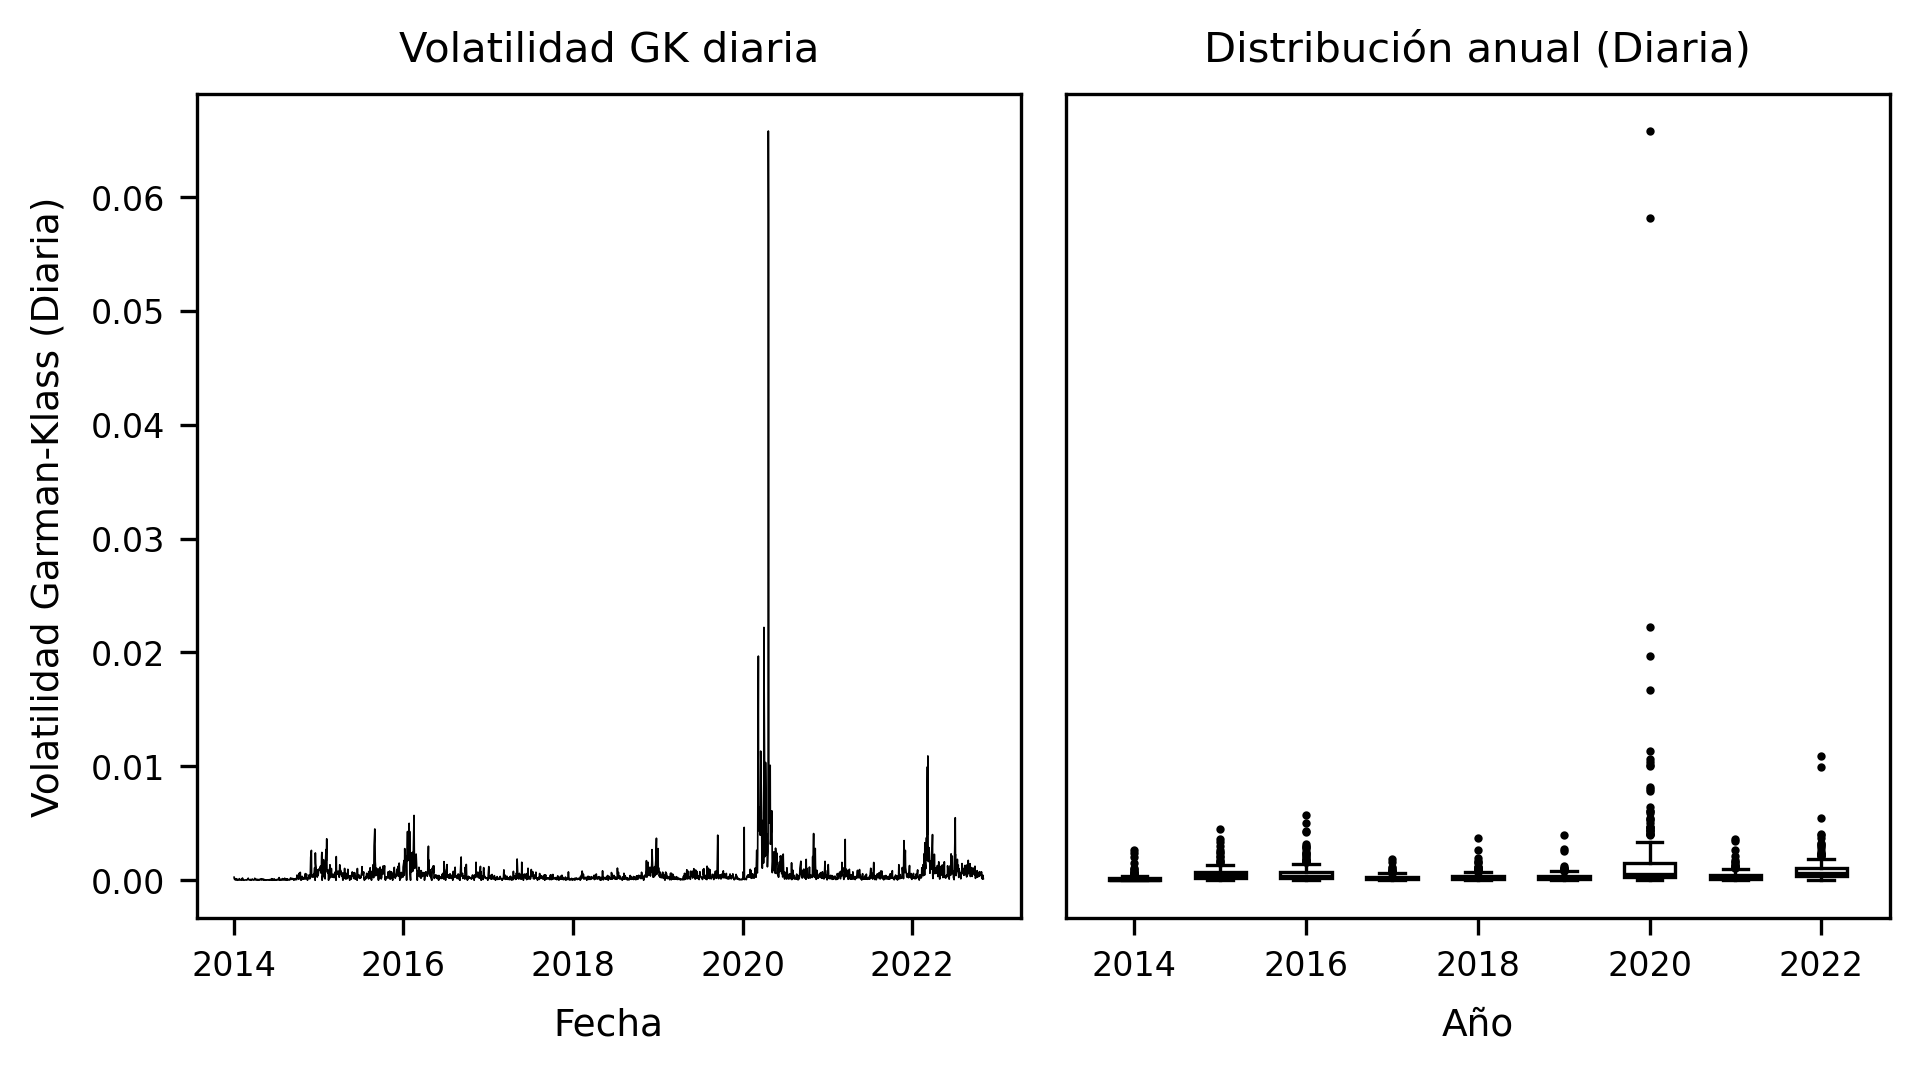

In [145]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Copia para graficar
df_plot = df_train.copy()
df_plot["year"] = df_plot.index.year

years = sorted(df_plot["year"].unique())
box_data_daily = [
    df_plot[df_plot["year"] == yr]["gk_daily"].dropna().values for yr in years
]

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(6.5, 3.8),
    dpi=300,
    subplot_kw={"box_aspect": 1},
)

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        labelsize=8,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

# Panel 1: Serie Temporal GK Diaria
ax1.plot(df_plot.index, df_plot["gk_daily"], color="black", linewidth=0.4)
ax1.set_xlabel("Fecha", fontsize=9, labelpad=6)
ax1.set_ylabel("Volatilidad Garman-Klass (Diaria)", fontsize=9, labelpad=6)
ax1.set_title("Volatilidad GK diaria", fontsize=10, pad=8)

ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax1.tick_params(
    axis="y",
    which="both",
    left=True,
    labelsize=8,
    direction="out",
    length=4,
    width=0.8,
    colors="black",
)

# Panel 2: Boxplots Anuales GK Diaria
bp = ax2.boxplot(
    box_data_daily,
    positions=years,
    widths=0.6,
    patch_artist=True,
    flierprops={
        "marker": "o",
        "markersize": 1.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markeredgewidth": 0.5,
    },
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 0.8},
)

even_years = [yr for yr in years if yr % 2 == 0]
ax2.set_xticks(even_years)
ax2.set_xticklabels(even_years, rotation=0)
ax2.set_xlim(min(years) - 0.8, max(years) + 0.8)

ax2.set_xlabel("Año", fontsize=9, labelpad=6)
ax2.set_title("Distribución anual (Diaria)", fontsize=10, pad=8)

ax2.tick_params(
    axis="y",
    which="both",
    left=False,
    right=False,
    labelleft=False,
    labelright=False,
)

plt.tight_layout()
plt.show()

In [67]:
# Preparar datos de volatilidad Garman-Klass
df_plot = df_train.dropna(subset=["gk_daily"]).copy()
gk = df_plot["gk_daily"]

# Suavizados móviles centrados
gk_5 = gk.rolling(window=5, center=True).mean()
gk_10 = gk.rolling(window=10, center=True).mean()
gk_21 = gk.rolling(window=21, center=True).mean()

# Crear figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(9, 6), dpi=300)

# Estilo común
for ax in axes.flat:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)
    ax.tick_params(
        axis="both",
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", pad=6)
    ax.tick_params(axis="y", pad=9)

# Paneles: título y serie
panels = [
    ("Volatilidad Garman-Klass", gk),
    ("Volatilidad Garman-Klass (suavizado 5 días)", gk_5),
    ("Volatilidad Garman-Klass (suavizado 10 días)", gk_10),
    ("Volatilidad Garman-Klass (suavizado 21 días)", gk_21),
]

# Configurar paneles
for ax, (title, series) in zip(axes.flat, panels):
    ax.plot(series.index, series.values, color="black", linewidth=1.0)
    ax.set_title(title, fontsize=10, pad=9)
    ax.set_ylabel("Volatilidad GK", fontsize=10, labelpad=9)
    if ax in axes[1, :]:
        ax.set_xlabel("Fecha", fontsize=10, labelpad=9)
    else:
        ax.set_xlabel("")

# Formato de ticks
# Panel 1: 4 decimales (valores pequeños)
axes[0, 0].yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))

# Los demás paneles conservan límites automáticos
# Eje Y a la derecha para paneles derechos
for ax in [axes[0, 1], axes[1, 1]]:
    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()

# Ajuste de espacio
fig.subplots_adjust(hspace=0.35, wspace=0.08)

render_figure_vector(fig)

## Correlación entre estimadores de volatilidad

Esta sección examina la dependencia entre los retornos al cuadrado y la volatilidad GK. El objetivo es determinar si, pese a la mayor eficiencia teórica del estimador GK, los retornos al cuadrado resultan adecuados para estudiar la volatilidad del Brent, en particular al aplicar ventanas de suavizado.

La correlación contemporánea entre ambas medidas aumentó al ampliar la ventana de suavizado. Este patrón fue consistente con la reducción del ruido de alta frecuencia por parte del filtrado de la variabilidad de corto plazo; la correlación entre los estimadores se incrementó y reveló una estructura común de volatilidad persistente. La relación entre las series mostró un carácter predominantemente lineal, con una asociación monótona que se fortaleció en ventanas largas.

In [20]:
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import HTML, display

df_corr = df_train[["squared_returns", "gk_daily"]].dropna()
r2 = df_corr["squared_returns"]
gk = df_corr["gk_daily"]

r2_5 = r2.rolling(window=5, center=True).mean()
r2_10 = r2.rolling(window=10, center=True).mean()
r2_21 = r2.rolling(window=21, center=True).mean()

gk_5 = gk.rolling(window=5, center=True).mean()
gk_10 = gk.rolling(window=10, center=True).mean()
gk_21 = gk.rolling(window=21, center=True).mean()

def corr_pair(x, y):
    x = x.dropna()
    y = y.loc[x.index]
    pearson_r, pearson_p = stats.pearsonr(x, y)
    spearman_r, spearman_p = stats.spearmanr(x, y)
    return pearson_r, pearson_p, spearman_r, spearman_p

alpha_1 = 0.05 / 4   # 0.0125
alpha_2 = 0.01 / 4   # 0.0025
alpha_3 = 0.001 / 4  # 0.00025

def format_stars(r, p):
    if p < alpha_3:
        stars = "***"
    elif p < alpha_2:
        stars = "**"
    elif p < alpha_1:
        stars = "*"
    else:
        stars = ""
    return f"{r:.3f}{stars}"

ventanas = {
    "Sin suavizar": (r2, gk),
    "5 días": (r2_5, gk_5),
    "10 días": (r2_10, gk_10),
    "21 días": (r2_21, gk_21),
}

rows = []
for nombre, (x, y) in ventanas.items():
    pear, p_pear, spear, p_spear = corr_pair(x, y)
    rows.append({
        "Ventana": nombre,
        "Pearson": format_stars(pear, p_pear),
        "Spearman": format_stars(spear, p_spear),
    })

df_corr_table = pd.DataFrame(rows)

styled_corr = (
    df_corr_table.style
    .hide(axis="index")
    .set_table_styles([
        {
            "selector": "",
            "props": [
                ("margin-left", "auto"),
                ("margin-right", "auto"),
                ("width", "auto"),
                ("border-collapse", "collapse"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("background-color", "#f2f2f2"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("border", "1px solid black"),
                ("padding", "10px"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid black"),
                ("padding", "10px"),
            ],
        },
        {"selector": "th:first-child", "props": [("text-align", "left")]},
        {"selector": "td:first-child", "props": [("text-align", "left")]},
    ])
)

display(
    HTML(
        "<div style='text-align: center; width: 100%;'>"
        + styled_corr.to_html()
        + "</div>"
    )
)

Ventana,Pearson,Spearman
Sin suavizar,0.681***,0.560***
5 días,0.820***,0.821***
10 días,0.879***,0.893***
21 días,0.929***,0.932***


La función de correlación cruzada (*cross-correlation function*, CCF) extendió el análisis de correlación global para examinar la estructura de retardos y contrastar la hipótesis de contemporaneidad entre ambas medidas de volatilidad. Sin suavizar, la correlación máxima se concentró en los retardos $-1$ y $0$, con valores cercanos a $0.7$. El resto de retardos permaneció bajo y dominado por ruido de alta frecuencia. Con la ventana de 5 días, la correlación en todos los retardos aumentó y alcanzó su máximo ($\approx 0.80$) en el retardo $-1$. La correlación en retardos lejanos, como $-12$ y $8$, también mostró un incremento, aunque en menor medida.

:::{admonition} Información: Función de correlación cruzada (CCF)
:class: info

La CCF mide la correlación entre dos series temporales desplazadas en el tiempo. Cada retardo $k$ cuantifica el grado de asociación entre una serie en el momento $t$ y la otra en $t+k$. La expresión del coeficiente de correlación cruzada muestral en términos de covarianza y varianza es:

$$
\rho_{xy}(k) = \frac{\mathrm{Cov}(x_t, y_{t+k})}{\sqrt{\mathrm{Var}(x_t) \cdot \mathrm{Var}(y_t)}}
$$

donde $\mathrm{Cov}(x_t, y_{t+k})$ denota la covarianza cruzada entre $x_t$ y $y_{t+k}$, y $\mathrm{Var}(x_t)$, $\mathrm{Var}(y_t)$ son las varianzas de cada serie calculadas sobre toda la muestra.
:::

Al ampliar la ventana a 10 y 21 días, la curva de correlación se suavizó. La correlación en retardos cercanos a cero superó 0.90, mientras el decaimiento de la dependencia se volvió menos pronunciado, en especial en los retardos negativos. 

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import ccf

df_corr = df_train[["squared_returns", "gk_daily"]].dropna()
r2 = df_corr["squared_returns"]
gk = df_corr["gk_daily"]

r2_5 = r2.rolling(window=5, center=True).mean()
r2_10 = r2.rolling(window=10, center=True).mean()
r2_21 = r2.rolling(window=21, center=True).mean()

gk_5 = gk.rolling(window=5, center=True).mean()
gk_10 = gk.rolling(window=10, center=True).mean()
gk_21 = gk.rolling(window=21, center=True).mean()

def compute_ccf(x, y, max_lag=20):
    x = x.dropna()
    y = y.loc[x.index]
    lags = np.arange(-max_lag, max_lag + 1)
    vals = np.zeros_like(lags, dtype=float)
    vals[lags >= 0] = ccf(x, y, adjusted=False)[:max_lag + 1]
    vals[lags < 0] = ccf(y, x, adjusted=False)[1:max_lag + 1][::-1]
    return lags, vals

variants = [
    ("Sin suavizar", r2, gk),
    ("Suavizado 5 días", r2_5, gk_5),
    ("Suavizado 10 días", r2_10, gk_10),
    ("Suavizado 21 días", r2_21, gk_21),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax in axes.flat:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)
    ax.tick_params(axis="both", labelsize=11, direction="out", length=4, width=0.8, colors="black")
    ax.grid(False)
    ax.set_ylim(-0.001, 1.00)
    ax.set_yticks(np.arange(0.0, 1.01, 0.1))
    ax.set_ylabel("Cross-correlation", fontsize=12, labelpad=11)

for idx, (ax, (title, x, y)) in enumerate(zip(axes.flat, variants)):
    lags, vals = compute_ccf(x, y)
    n = len(x)
    conf_level = 1.96 / np.sqrt(n)

    ax.vlines(lags, ymin=0, ymax=vals, color="black", linewidth=1.0)

    ax.axhline(0, color="black", linewidth=0.5)

    ax.axhline(conf_level, color="blue", linestyle="--", linewidth=1.0)
    ax.axhline(-conf_level, color="blue", linestyle="--", linewidth=1.0)

    ax.set_title(title, fontsize=13, pad=12)

    if idx < 2:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("Retardo", fontsize=12, labelpad=11)

    if idx % 2 == 1:
        ax.set_ylabel("")
        ax.tick_params(axis="y", which="both", left=False, labelleft=False)

fig.subplots_adjust(hspace=0.30, wspace=0.08)
render_figure_vector(fig)

Los resultados del análisis de dependencia entre series sugieren que los retornos al cuadrado constituyen una aproximación adecuada de la volatilidad diaria del Brent frente al estimador GK, en particular al aplicar una ventana de suavizado. El suavizado redujo el ruido de alta frecuencia y reveló la estructura común de volatilidad. La correlación en retardos distintos de cero aumentó con la amplitud de la ventana, en especial en los retardos negativos, como consecuencia de la autocorrelación introducida por el filtrado en cada serie. Una ventana de una semana bursátil (5 días) fue suficiente para filtrar la mayor parte del ruido y mantuvo ese efecto en un nivel reducido.